# Interpolation

## Introduction

In **interpolation** we start from a table of (distinct) values $x_i, y_i$:

| $\mathbf{x}$  | $\mathbf{y}$  |
|:-:|:-:|
| $x_0$  | $y_0$  |
| $x_1$  | $y_1$  |
| $\dots$   | $\dots$ |
| $x_{n-1}$| $y_{n-1}$|

and we want to determine intermediate values. If we want to determine values outside the range of $x$ in the table, we speak of **extrapolation**.

In **interpolation** we connect the points by assuming some function and adding the condition that the function *must* pass through the given points.

In **approximation** (curve fitting) we assume a function that fits the data as closely as possible (according to a chosen criterion).

Let us look at an example:

| $\mathbf{x}$  | $\mathbf{y}$  |
|:-:|:-:|
| 1.0  | 0.54030231  |
| 2.5  | -0.80114362  |
| 4.0   | -0.65364362 |

In interpolation we start from a table of values. So that we can easily show the error later, we generated the table above using the expression $y = \cos(x)$!

Let us prepare a numerical example; first we import the packages:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

Next we prepare the table and the plot:

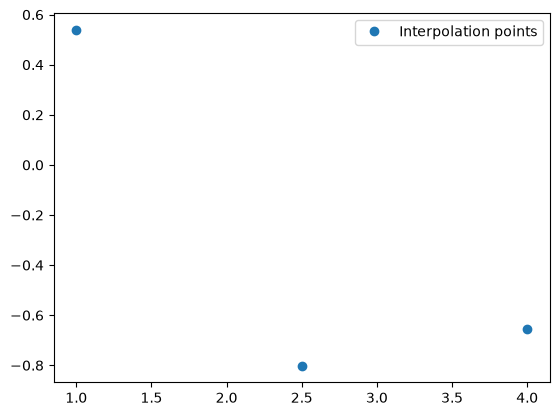

In [2]:
n = 3
x = np.linspace(1, 4, n)
f = np.cos # generalize the interpolated function (you can change it to another function)
f_name = f.__str__().split('\'')[1] # automatically take the name of the function
y = f(x)# + np.random.rand(len(x))*0.3
plt.plot(x, y, 'o', label='Interpolation points');
plt.legend();

## Polynomial interpolation

Polynomial interpolation seems most suitable, since it is simple!

A polynomial of degree $n-1$:

$$
y = a_0\,x^{n-1} +a_1\,x^{n-2} +\cdots + a_{n-2}\,x + a_{n-1}.
$$

is defined by $n$ constants $a_i$. To determine the $n$ constants, we need $n$ (distinct) equations. For each pair $x_i, y_i$ we can therefore write:

$$
y_i = a_{0}\,x_i^{n-1} +a_{1}\,x_i^{n-2} +\cdots + a_{n-2}\,x_i + a_{n-1}.
$$

Since we are given $n$ pairs, we can determine the $n$ unknown constants $a_i$ that define a polynomial of degree $n-1$. The system of $n$ linear equations can be written as:

$$
\begin{bmatrix}
x_{0}^{n-1}&x_{0}^{n-2}&\dots&x_{0}^0\\
x_{1}^{n-1}&x_{1}^{n-2}&\dots&x_{1}^0\\
&&\vdots&&\\
x_{n-1}^{n-1}&x_{n-1}^{n-2}&\dots&x_{n-1}^0\\
\end{bmatrix}
\begin{pmatrix}
a_{0}\\
a_{1}\\
\vdots\\
a_{n-1}
\end{pmatrix}=
\begin{pmatrix}
y_{0}\\
y_{1}\\
\vdots\\
y_{n-1}
\end{pmatrix}
$$

We write the system of linear equations in the form:

$$
\mathbf{M}\,\mathbf{a}=\mathbf{b}.
$$

Let us define the coefficient matrix $\mathbf{M}$:

In [3]:
M = np.asarray([[_**p for p in reversed(range(len(x)))] for _ in x])
M

array([[ 1.  ,  1.  ,  1.  ],
       [ 6.25,  2.5 ,  1.  ],
       [16.  ,  4.  ,  1.  ]])

We compute the coefficients $a_{0}, a_{1},\dots$:

In [4]:
solution = np.linalg.solve(M, y)
solution

array([ 0.33087687, -2.05236633,  2.26179176])

Let us prepare the interpolation polynomial as a Python function:

In [5]:
def y_function(x, solution):
    A = np.asarray([[_**p for p in reversed(range(len(solution)))] for _ in x])
    return A.dot(solution)

Plotting the interpolation polynomial on a denser grid of points:

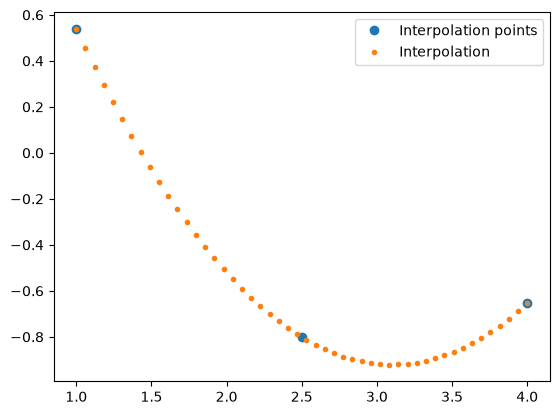

In [6]:
xint = np.linspace(np.min(x), np.max(x), 50)
yint = y_function(xint, solution)
plt.plot(x, y, 'o', label='Interpolation points')
plt.plot(xint, yint, '.',label='Interpolation')
plt.legend();

The drawbacks of the procedure above are:

 * the number of numerical operations grows proportionally to $n^3$,
 * the problem can be ill-conditioned (as the polynomial degree increases, the ill-conditioning grows rapidly):

In [7]:
np.linalg.cond(M)

np.float64(71.3022787031109)

*Instruction*: go back a few lines and change the number of interpolation points $n$ to a higher value (e.g., 10).

## Lagrange method

The *Lagrange* method does not require solving a system of equations and, from the standpoint of the number of computational operations (it grows proportionally to $n^2$ ([source](http://www.ams.org/journals/mcom/1970-24-109/S0025-5718-1970-0258240-X/S0025-5718-1970-0258240-X.pdf))), it is better than the previously presented polynomial interpolation (where the number of operations grows proportionally to $n^3$), in which we solved a system of linear equations. The solution, of course, is exactly the same!

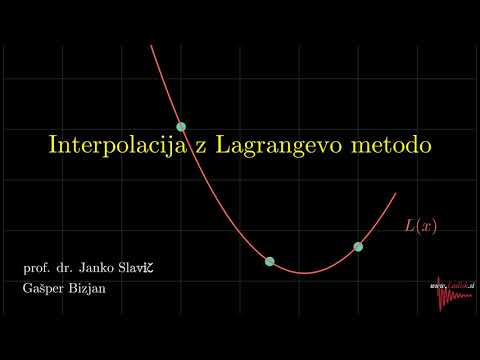

In [8]:
from IPython.display import YouTubeVideo
YouTubeVideo('c_TbU8XBHsw', width=800, height=300)

The Lagrange interpolation polynomial of degree $n-1$ is defined as:

$$
P_{n-1}(x)=\sum_{i=0}^{n-1}y_i\,l_i(x),
$$

where $l_i$ is the Lagrange polynomial:

$$
l_i(x)=\prod_{j=0, j\ne i}^{n-1} \frac{x-x_j}{x_i-x_j}.
$$

Let us look at the interpolation for the $x$ and $y$ data shown above.

First let us define the Lagrange polynomials $l_i(x)=\prod_{j=0, j\ne i}^{n-1} \frac{x-x_j}{x_i-x_j}$:

In [9]:
def lagrange(x, x_int, i):
    """ Returns the values of the i-th Lagrange polynomial

    x: independent variable (scalar or numerical array)
    x_int: list of interpolation points
    i: index of the polynomial
    """
    Lx = 1.0
    for j in range(len(x_int)):
        if j != i:
            Lx *= (x-x_int[j]) / (x_int[i]-x_int[j])
    return Lx

In [10]:
def figure(i=0):
    xint = np.linspace(np.min(x), np.max(x), 30)
    plt.plot(x, y, 'o', label='Interpolation points')
    plt.axhline(0, color='k', linewidth=0.3);
    plt.plot(xint, lagrange(xint, x_int=x, i=i), '.',label=f'Lagrange polynomial i={i}');
    for _ in x:
        plt.axvline(_, color='r', linewidth=0.5);
    plt.legend()
    plt.show()

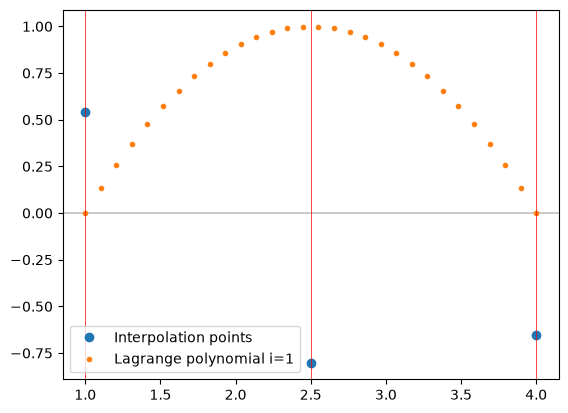

In [11]:
figure(i=1)

We observe that the $i$-th Lagrange polynomial has the value 1 at $x_i$, and zero at the other given points!

So if we multiply the Lagrange polynomial for $i=0$ by $y_0$, we will obtain the correct value at $x=x_0$, and zero at the other interpolation points; let us therefore implement the Lagrange interpolation polynomial:

$$
P_{n-1}(x)=\sum_{i=0}^{n-1}y_i\,l_i(x),
$$


In [12]:
def lagrange_interpolation(x, x_int, y_int):
    """ Returns the values of the Lagrange interpolation

    x: independent variable (scalar or numerical array)
    x_int: abscissa of the interpolation points
    y_int: ordinate of the interpolation points
    """
    y = 0.
    for i in range(len(x_int)):
        Lx = 1.0
        for j in range(len(x_int)):
            if j != i:
                Lx *= (x-x_int[j]) / (x_int[i]-x_int[j])
        y += y_int[i] * Lx
    return y

Let us prepare the figure:

In [13]:
def figure(i=0):
    xint = np.linspace(np.min(x), np.max(x), 30)
    plt.plot(x, y, 'o', label='Interpolation points')
    plt.plot(xint, lagrange(xint, x_int=x, i=i), '.',label=f'Lagrange polynomial i={i}');
    plt.plot(xint, lagrange_interpolation(xint, x_int=x, y_int=y), '.',label=f'Lagrange interp. polynomial');
    plt.axhline(0, color='k', linewidth=0.3);
    for _ in x:
        plt.axvline(_, color='r', linewidth=0.5);
    plt.legend()
    plt.show()

From `ipywidgets` we import ``interact``, which is a powerful tool for automatically generating a (simple) user interface within the `jupyter` environment. Here we will use a relatively simple interaction with the figure; for an overview of all the capabilities we refer the curious reader to the [documentation](http://ipywidgets.readthedocs.io/en/latest/examples/Using%20Interact.html).

Importing the ``interact`` function

In [14]:
from ipywidgets import interact

In [15]:
interact(figure);

interactive(children=(IntSlider(value=0, description='i', max=1), Output()), _dom_classes=('widget-interact',)…

From the figure we see that the Lagrange polynomial $i$ has the value 1 only at $x_i$ and the value zero at the other points $\ne i$; when we multiply the Lagrange polynomial $l_i(x)$ by $y_i$ we satisfy the $i$-th point from the table. Consequently, the Lagrange interpolation, with the sum of the Lagrange polynomials, interpolates the table.

Polynomial interpolation with a large number of points can be an ill-conditioned problem and we therefore advise against it.

### Error estimate

If $f(x)$ is the function we are interpolating and $P_{n-1}(x)$ is the interpolation polynomial of degree $n-1$, then it can be shown (see, e.g.: Burden, Faires, Burden: Numerical Analysis) that the error of polynomial interpolation is:

$$
e=f(x)-P_{n-1}(x)=\frac{f^{(n)}(\xi)}{n!}\,(x-x_0)\,(x-x_1)\,\cdots\,(x-x_{n-1}),
$$

where $f^{(n)}$ is the derivative of the function, $n-1$ is the degree of the interpolation polynomial, and $\xi$ is a value on the interpolated interval $[x_0, x_{n-1}]$.

### Example

Here we will look at the interpolation of the points:

In [16]:
x = np.array([0.        ,  0.52359878,  1.04719755,  1.57079633])
y = np.array([ 0.       ,  0.5      ,  0.8660254,  1.       ])

Let us plot the points:

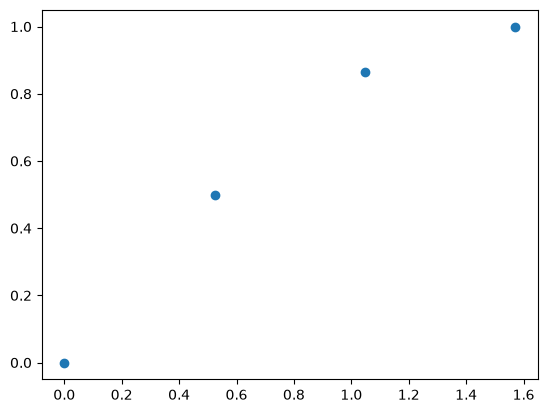

In [17]:
plt.plot(x, y, 'o');

Linear interpolation for the value at `x=1.57079633/2`:

In [18]:
y_linear = lagrange_interpolation(x=x[-1]/2, x_int=x[1:3], y_int=y[1:3])
y_linear

np.float64(0.6830127)

Quadratic:

In [19]:
y_quadratic = lagrange_interpolation(x=x[-1]/2, x_int=x[0:3], y_int=y[0:3])
y_quadratic

np.float64(0.6997595236464176)

Cubic

In [20]:
y_cubic = lagrange_interpolation(x=x[-1]/2, x_int=x, y_int=y)
y_cubic

np.float64(0.705889286844634)

### Example of the error estimate

In interpolation we usually do not know the function $f(x)$, and we estimate the error using the formula:

$$
e=\frac{f^{(n)}(\xi)}{n!}\,(x-x_0)\,(x-x_1)\,\cdots\,(x-x_n).
$$

Here the value $\xi$ is not known; since in the case of linear interpolation ($n=2$) the second derivative of the sine function ($f^{(n)}$) is between -1 and +1, it holds that:

$$
|e|\le\left|\frac{-1}{2!}\,(\pi/4-\pi/6)\,(\pi/4-\pi/3)\right|=\frac{1}{2}\,\frac{\pi}{12}\,\frac{\pi}{12}=\frac{\pi^2}{288}=0.034
$$

In addition to the **Lagrange method**, we could here also look at the **Newton method** of interpolation.

### Interpolation using `scipy`

Let us look at interpolation within the module `scipy.interpolate` ([documentation](https://docs.scipy.org/doc/scipy/reference/interpolate.html)).

We will use the function for interpolating a table with splines, `scipy.interpolate.interp1d` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d)):

```python
interp1d(x, y, kind='linear', axis=-1, copy=True, bounds_error=None, fill_value=nan, assume_sorted=False)
```

We must provide at least two parameters: the lists of interpolation points `x` and `y`. The default parameter `kind='linear'` means that we interpolate with a piecewise linear function. `interp1d` returns a function `f` that we call (e.g., `y = f(x)`) to compute the interpolated value.

The `kind` parameter can also be, e.g.: `'zero'`, `'slinear'`, `'quadratic'` and `'cubic'`; in that case an interpolation spline of order 0, 1, 2, or 3 is used. We will look at splines in the next section.

**Note**: `interp1d` is marked as *legacy* in SciPy (an older interface that is no longer developed but still works). For new programs SciPy recommends `numpy.interp` (piecewise linear interpolation), `scipy.interpolate.CubicSpline` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html)) and `scipy.interpolate.make_interp_spline` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_interp_spline.html)); all of them return an object that we call in the same way as `f` below.

In [21]:
from scipy.interpolate import interp1d

Let us define the data table:

In [22]:
x = np.array([ 1.        ,  2.14285714,  3.28571429,  4.42857143,  5.57142857,
        6.71428571,  7.85714286,  9.        ])

y = np.array([ 0.84147098,  0.84078711, -0.14362322, -0.95999344, -0.65316501,
        0.41787078,  0.999995  ,  0.41211849])

In [23]:
len(x)

8

In [24]:
from scipy.interpolate import interp1d

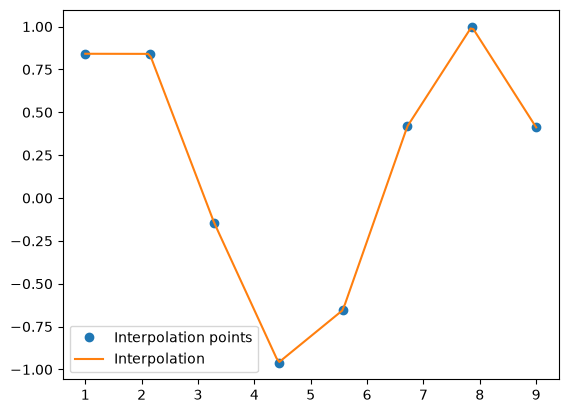

In [25]:
f = interp1d(x, y, kind='linear')
x_g = np.linspace(x[0], x[-1], 20*len(x)-1)
plt.plot(x, y, 'o', label='Interpolation points')
plt.plot(x_g, f(x_g), '-', label='Interpolation')
plt.legend();

## Cubic splines

Before we go into the theory of splines, let us look at the result we obtain by calling the function `interp1d` with the parameter `kind='cubic'` (the result is a cubic spline).

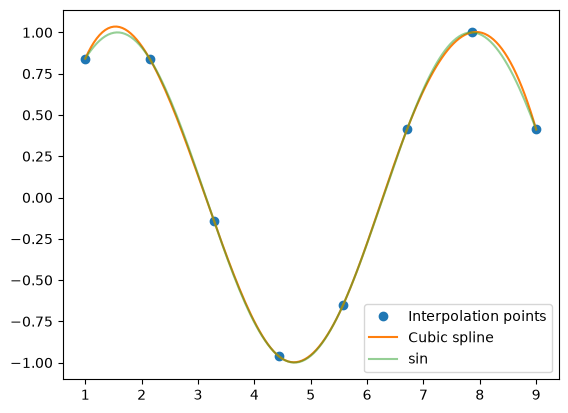

In [26]:
f = interp1d(x, y, kind='cubic')
plt.plot(x, y, 'o', label='Interpolation points')
plt.plot(x_g, f(x_g), '-', label='Cubic spline')
plt.plot(x_g, np.sin(x_g), label='sin', alpha=0.5)
plt.legend();

Cubic splines are a common method of interpolation.

We require that: $x_0<x_1< \cdots <x_n$.

From point $x_i$ to $x_{i+1}$ let the spline be the
polynomial:

$$
f_{i,i+1}(x)= a_{i,3}\,x^3+a_{i,2}\,x^2+a_{i,1}\,x+a_{i,0},
$$

where the values of the constants $a_{i,j}$ are unknown.

If, for example, we have $n+1$ points, then $n$ polynomials need to be determined.

The entire spline over the $n+1$ points is defined by:

$$
f(x) = \left\{
\begin{array}{rcl}
f_{0,1}(x); && x\in[x_0, x_1)\\
f_{1,2}(x); && x\in[x_1, x_2)\\
&\vdots&\\
f_{n-1,n}(x); && x\in[x_{n-1}, x_n]
\end{array}
\right.
$$

Each polynomial $f_{i,i+1}$ is defined by 4 constants $a_{i,j}$; in total we therefore have to compute $4n$ constants $a_{i,j}$.


**How do we determine the constants $a_{i,j}$?**

To determine the $4n$ unknowns we need $4n$ equations. Let us look at how we obtain them:

* $n$ equations come from the interpolation condition: $y_i=f_{i,i+1}(x_i),\quad i=0,1,2,\dots,n-1$
* 1 equation from the last point: $y_n=f_{n-1,n}(x_n)$
* $3(n-1)$ equations come from the $C^2$ continuity condition:

$$
\lim_{x\rightarrow x_i^-}f(x)=\lim_{x\rightarrow x_i^+}f(x),
$$

$$
\lim_{x\rightarrow x_i^-}f'(x)=\lim_{x\rightarrow x_i^+}f'(x)
$$

and

$$
\lim_{x\rightarrow x_i^-}f''(x)=\lim_{x\rightarrow x_i^+}f''(x).
$$

In total we have defined $4n-2$ equations, so two are still missing!

The different types of splines differ in how we determine these two equations. In what follows we will look at *natural cubic splines*.

### Natural cubic splines

*Natural cubic splines* are based on the idea of the Euler beam:

$$
E\,I\,\frac{\textrm{d}^4y}{\textrm{d}x^4}=q(x),
$$

where $E$ is the elastic modulus, $I$ the second moment of area, and $q(x)$ the external distributed load. Since there is no external distributed load ($q(x)=0$), it holds that:

$$
E\,I\,\frac{\textrm{d}^4y}{\textrm{d}x^4}=0.
$$

It follows that at each point a thin beam can be described by a third-degree polynomial.

$C^2$ continuity is ensured provided that the intermediate supports of the beam are hinges (so the moment has no discontinuous change).

The 2 missing unknowns for natural cubic splines are determined from the condition that the moment at the ends is equal to zero (hinged support):

$$
f''(x_{0})=0\qquad\textrm{and}\qquad f''(x_{n})=0
$$

The derivation is shown in more detail in the book Kiusalaas J: Numerical Methods in Engineering with Python 3, 2013, page 120 (see also J. Petrišič: Interpolacija, Faculty of Mechanical Engineering, 1999); a detailed derivation is beyond the scope of this book.

Here we will look only at the final result, which can be derived under the conditions above. In the case of an equidistant partition $h=x_{i+1}-x_i$ we thus derive the system of equations ($i=1,\dots,n-1$):

$$
k_{i-1} + 4 k_{i} + k_{i+1}  =  \frac{6}{h^2} \left(y_{i-1} -2 y_{i} +y_{i+1} \right).
$$

where the unknown $k_i$ is the second derivative of the piecewise function $k_i = f''_{i,i+1}(x_i)$.

We obtain a solvable system of equations if we add the boundary conditions for natural cubic splines:

$$
k_0=k_n=0.
$$

Once we determine the unknowns $k_i$, we use them in the piecewise defined function:

$$
f_{i,i+1}(x)=\frac{k_{i+1}}{6}\left(\frac{(x-x_{i})^3}{h}-(x-x_{i})\,h\right)
-\frac{k_{i}}{6}\left(\frac{(x-x_{i+1})^3}{h}-(x-x_{i+1})\,h\right)
+\frac{y_{i+1}\,(x-x_{i})-y_i\,(x-x_{i+1})}{h}.
$$

### Numerical implementation

First we prepare a function that, for the given interpolation points, solves the system of linear equations and returns the coefficients $k_i$:

In [27]:
def cubic_splines_coefficients(x, y):
    """ Returns the cubic spline coefficients `k`, the coefficient matrix `A`, and the constants.

    x and y represent the list of known values; x must be equidistant.
    """
    n = len(x)
    A = np.zeros((n, n)) # prepare the coefficient matrix
    h = x[1]-x[0] # step h
    for i in range(n):
        if i==0 or i==n-1:
            A[i,i] = 1. # k_0 and k_n are zero, so here we put 1
                       # and in the constant vector we will put 0, so k_0 and k_n will be 0
        else:
            A[i, i-1:i+2] = np.asarray([1., 4., 1.])
    b = np.zeros(n)
    b[1:-1] = (6/h**2)*(y[:-2] - 2*y[1:-1] + y[2:]) # right-hand side of the equation above
    k = np.linalg.solve(A,b)
    return k, A, b

Note: in the linear problem above, the computation can be sped up greatly if we take advantage of the tridiagonality of the coefficient matrix! (See the [answer on stackoverflow.com](https://stackoverflow.com/questions/23120164/optimize-ax-b-solution-for-a-tridiagonal-coefficient-matrix)).

Let us look at an example of computing the coefficients:

In [28]:
x = np.asarray([1, 2, 3, 4, 5])
y = np.asarray([0, 1, 0, 1, 0])

k, A, b = cubic_splines_coefficients(x, y)
print('Coefficient matrix A of the linear system:\n', A)
print('Constant vector b of the linear system:     ', b)
print('The coefficients k are:', k)

Coefficient matrix A of the linear system:
 [[1. 0. 0. 0. 0.]
 [1. 4. 1. 0. 0.]
 [0. 1. 4. 1. 0.]
 [0. 0. 1. 4. 1.]
 [0. 0. 0. 0. 1.]]
Constant vector b of the linear system:      [  0. -12.  12. -12.   0.]
The coefficients k are: [ 0.         -4.28571429  5.14285714 -4.28571429  0.        ]


Next we also need the cubic polynomial in a given interval; let us implement the expression:

$$
f_{i,i+1}(x)=\frac{k_{i+1}}{6}\left(\frac{(x-x_{i})^3}{h}-(x-x_{i})\,h\right)
-\frac{k_{i}}{6}\left(\frac{(x-x_{i+1})^3}{h}-(x-x_{i+1})\,h\right)
+\frac{y_{i+1}\,(x-x_{i})-y_i\,(x-x_{i+1})}{h}
$$

In [29]:
def cubic_splines(k, x, y, x_find):
    """ Returns the cubic spline at the partition `xint`.

    :param k: cubic spline coefficients
    :param x and y: known values, x must be equidistant
    :param x_find: values where we want to compute the cubic spline
    """
    h = x[1] - x[0]
    i = int((x_find-x[0])//h)
    if i >= len(k)-1:
        i = len(k)-2
    out = ((x_find - x[i])**3/h - (x_find - x[i])*h)*k[i+1]/6.0 \
        - ((x_find - x[i+1])**3/h - (x_find - x[i+1])*h)*k[i]/6.0 \
        + (y[i+1]*(x_find - x[i]) \
        - y[i]*(x_find - x[i+1]))/h
    return out

We compute the interpolated values:

In [30]:
xint = np.linspace(np.min(x), np.max(x), 50)
yint = np.asarray([cubic_splines(k, x, y, _) for _ in xint])

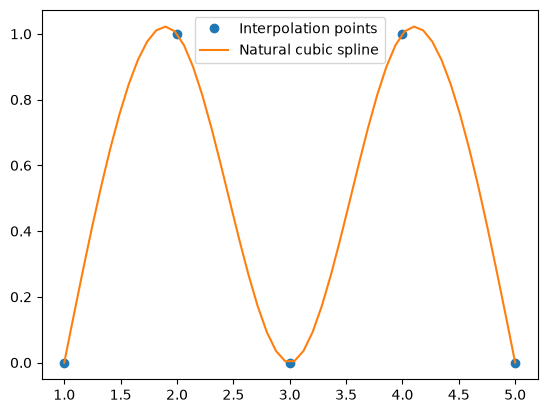

In [31]:
plt.plot(x, y, 'o', label='Interpolation points')
plt.plot(xint, yint, label='Natural cubic spline')
plt.legend();

# Additional

* 2D interpolation: https://www.youtube.com/watch?v=_cJLVhdj0j4
* Machine translation: https://pypi.org/project/goslate)

## A few comments on the ``scipy.interpolate`` module

SciPy has a large number of different interpolations implemented ([see the documentation](https://docs.scipy.org/doc/scipy/reference/interpolate.html)). From the standpoint of usage, we will touch here on the object-oriented implementation `scipy.interpolate.InterpolatedUnivariateSpline` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.InterpolatedUnivariateSpline.html)) (the older approach is based on functional programming, see the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.splrep.html) of `scipy.interpolate.splrep`):

```python
InterpolatedUnivariateSpline(x, y, w=None, bbox=[None, None], k=3, ext=0, check_finite=False)
```

When initializing the `InterpolatedUnivariateSpline` object we must pass the interpolation points `x` and `y`. The argument `k`, with a default value of `k=3`, defines the order of the interpolation spline (`1<=k<=5`). An important optional parameter is also `w`, which defines the weights of the individual interpolation points (we use it if we want to give greater emphasis to certain regions).

**Note**: `InterpolatedUnivariateSpline` (and the related `UnivariateSpline`) have been marked as *legacy* since SciPy 1.15; the more modern equivalents are `make_interp_spline` (interpolation) and `make_smoothing_spline` or `make_splrep` (approximation, see the next lecture). The object interface below still works and, being clearer, is well suited for learning.

In [32]:
from scipy.interpolate import InterpolatedUnivariateSpline

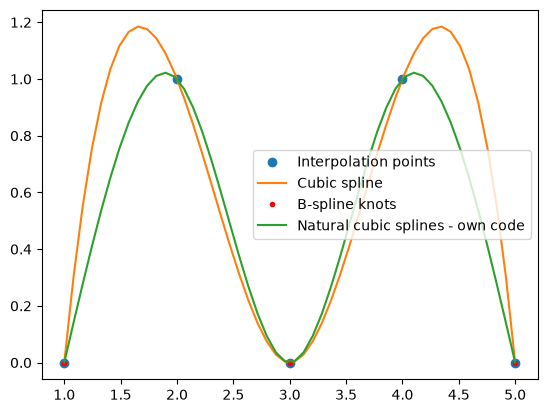

In [33]:
spl = InterpolatedUnivariateSpline(x, y, k=3) # check out the options!
plt.plot(x, y, 'o', label='Interpolation points')
plt.plot(xint, spl(xint), label='Cubic spline');
plt.plot(spl.get_knots(), spl(spl.get_knots()), 'r.', label='B-spline knots')
plt.plot(xint, yint, label='Natural cubic splines - own code');
plt.legend();

Since these are B-splines, the result is different from the one we derived with natural cubic splines. Unlike natural cubic splines, which have knots at the interpolation points, the knots of B-splines adapt to the data. In this particular example the knots are at the points:

In [34]:
spl.get_knots()

array([1., 3., 5.])

### Differentiating, integrating ... splines

Splines can be differentiated and integrated, since they are polynomials. The ``InterpolatedUnivariateSpline`` object is thus already prepared for differentiation, integration, finding roots (zeros), knots ... (see the [documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.InterpolatedUnivariateSpline.html)).

For the first derivative of the spline in the object `spl`, for example, we use the method ``spl.derivative(1)``, which returns a new spline object (its order is now lower by 1):

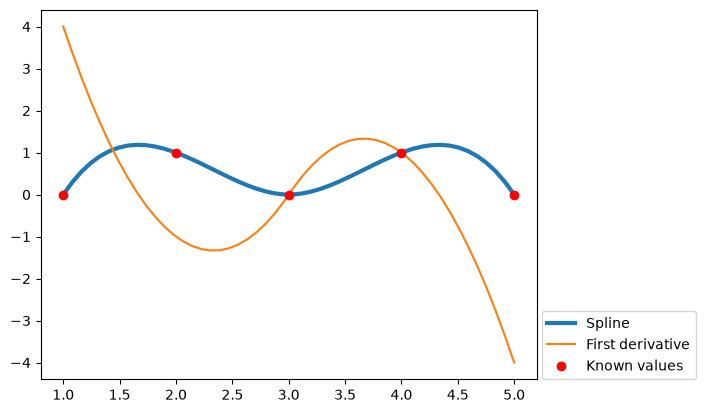

In [35]:
spl1 = spl.derivative(1)
#spl2 = spl.derivative(2)
#spl3 = spl.derivative(3)
plt.plot(xint, spl(xint), lw=3, label='Spline')
plt.plot(xint, spl1(xint), label='First derivative')
#plt.plot(xint, spl2(xint), label='Second derivative')
#plt.plot(xint, spl3(xint), label='Third derivative')
plt.plot(x, y, 'ro', label='Known values')
#plt.plot(spl.get_knots(), spl(spl.get_knots()), 'k.', label='B-spline knots')
plt.legend(loc=(1.01, 0));

---

# Questions for exercises

---

## Lagrange method

In [36]:
def lagrange_i(x, x_int, i):
    """ Returns the values of the i-th Lagrange polynomial

    x: list of x values of the points we are interpolating
    x_int: independent variable (points at which we seek values)
    i: index of the Lagrange polynomial
    """
    Li = 1.0
    for j in range(len(x)):

        if j != i:
            Li *= (x_int-x[j]) / (x[i]-x[j])
    return Li

In [37]:
# Example
x = np.linspace(0,1,4)
y = np.random.rand(len(x))
x_int = np.linspace(np.min(x), np.max(x), 50)

**Question 1:** Prepare a function ``lagrange_interpolation`` that takes as arguments the numerical arrays ``x`` and ``y`` of the coordinates of the known points, as well as the numerical array ``x_int`` of the coordinates at which we are interested in the interpolated values.

For each of the known points $x_i$, it should use the function ``lagrange_i`` to compute the values of the polynomial $l_i$ at the points ``x_int``, and finally compute and return the values ``y_int`` $= P_n($ ``x_int`` $)$ by computing the sum:

$$P_n(x_{\text{int}}) = \sum_{i=0}^{n}y_il_i(x_{\text{int}})$$


**Question 2:** Prepare a set of five points ``x``, evenly distributed over the interval $x\in[0,2 \pi]$, and the corresponding values ``y``, defined as:

$$y = \sin(x)$$

For 100 points ``x_int`` on the same interval, compute the interpolation curve (use the appropriate function from `scipy`).

On the same plot, show the points ``(x,y)``, the interpolation curve, and the true values of $y$ at the points ``x_int``.

How would you compute the interpolation error as a function of the value of ``x_int``? (We know the true values of $y$!)

----------

## Cubic splines

In [41]:
# Example
x = np.linspace(0,1,10)
y = np.random.rand(len(x)) - 0.5
x_int = np.linspace(x[0], x[-1], 100)

Comparison of ``InterpolatedUnivariateSpline`` and ``interp1d``:

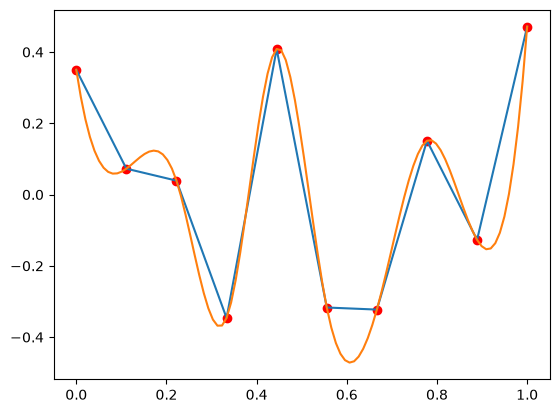

In [42]:
plt.plot(x, y, 'ro')
plt.plot(x_int, interp1d(x, y)(x_int))
plt.plot(x_int, InterpolatedUnivariateSpline(x, y)(x_int))

**Question 3:** Using any ``scipy`` function, prepare a graphical display of the interpolation of the prepared points ``(x, y)`` with linear, quadratic, and cubic splines.

**Question 4:** For the points ``x, y``, compare the cubic spline interpolation curve ``scipy.InterpolatedUnivariateSpline`` with the result of the Lagrange interpolation.

**Question 5:** For the cubic interpolation spline curve obtained in the previous problem using the ``scipy`` function, find the zeros.

Display the results graphically.

**Question 6:** Graphically display the spline curve from the previous problem and its derivatives.

**Question 7:** The given points ``(t, a)`` represent the measured acceleration profile of a car in the direction of travel. Using ``scipy.InterpolatedUnivariateSpline``, determine the interpolation curve with 2nd-order splines at the times ``t_int``.

Use the existing function and also determine and graphically display the velocity and distance-traveled curves (hint: ``help(InterpolatedUnivariateSpline)``).

In [47]:
# Data
t = np.array([0, 1, 2, 3, 4, 5])
a = np.array([5, 3, 0, 0, -4, -3])
t_int = np.linspace(t[0], t[-1], 50)